In [50]:
import pvlib
import pandas as pd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import datetime 
import pytz
import pandas as pd
import numpy as np
import requests
import math

In [51]:
lat = 47.99
long = 139.53
time_zone = 'Asia/Vladivostok'
loc = pvlib.location.Location(lat, long, time_zone)

In [52]:
start_time = datetime.datetime(2025, 1, 1, 0)
end_time = datetime.datetime(2025, 12, 31, 23)
model_freq = '1h'

date_array = pd.date_range(start = start_time,
                           end = end_time,
                           freq = model_freq,
                           tz = time_zone) 
DOY_summer = 172

In [53]:
SPA_obj = pvlib.solarposition.spa_python(date_array,
                                         loc.latitude,
                                         loc.longitude,
                                         loc.altitude)

SPA_summer = SPA_obj.iloc[(DOY_summer - 1) * 24 : DOY_summer * 24]

In [54]:
DNI_extra = pvlib.irradiance.get_extra_radiation(date_array,1370,'spencer')
DNI_summer = DNI_extra.iloc[(DOY_summer -1) * 24 : DOY_summer * 24]

In [55]:
rel_airmass_obj = pvlib.atmosphere.get_relative_airmass(zenith = SPA_summer['zenith'],
                                                       model = 'kastenyoung1989')
                                 
abs_airmass_obj = pvlib.atmosphere.get_absolute_airmass(airmass_relative = rel_airmass_obj,
                                                        pressure = 99725.13)

linke_turbidity_obj = pvlib.clearsky.lookup_linke_turbidity(date_array,
                                                            loc.latitude,
                                                            loc.longitude,
                                                           )
linke_turbidity_obj = linke_turbidity_obj.iloc[(DOY_summer - 1) * 24 : DOY_summer * 24]

SCS_summer = pvlib.clearsky.ineichen(SPA_summer['apparent_zenith'],
                        airmass_absolute = abs_airmass_obj ,
                        linke_turbidity = linke_turbidity_obj,
                        altitude = loc.altitude ,
                        dni_extra = DNI_summer,
                        perez_enhancement = False)

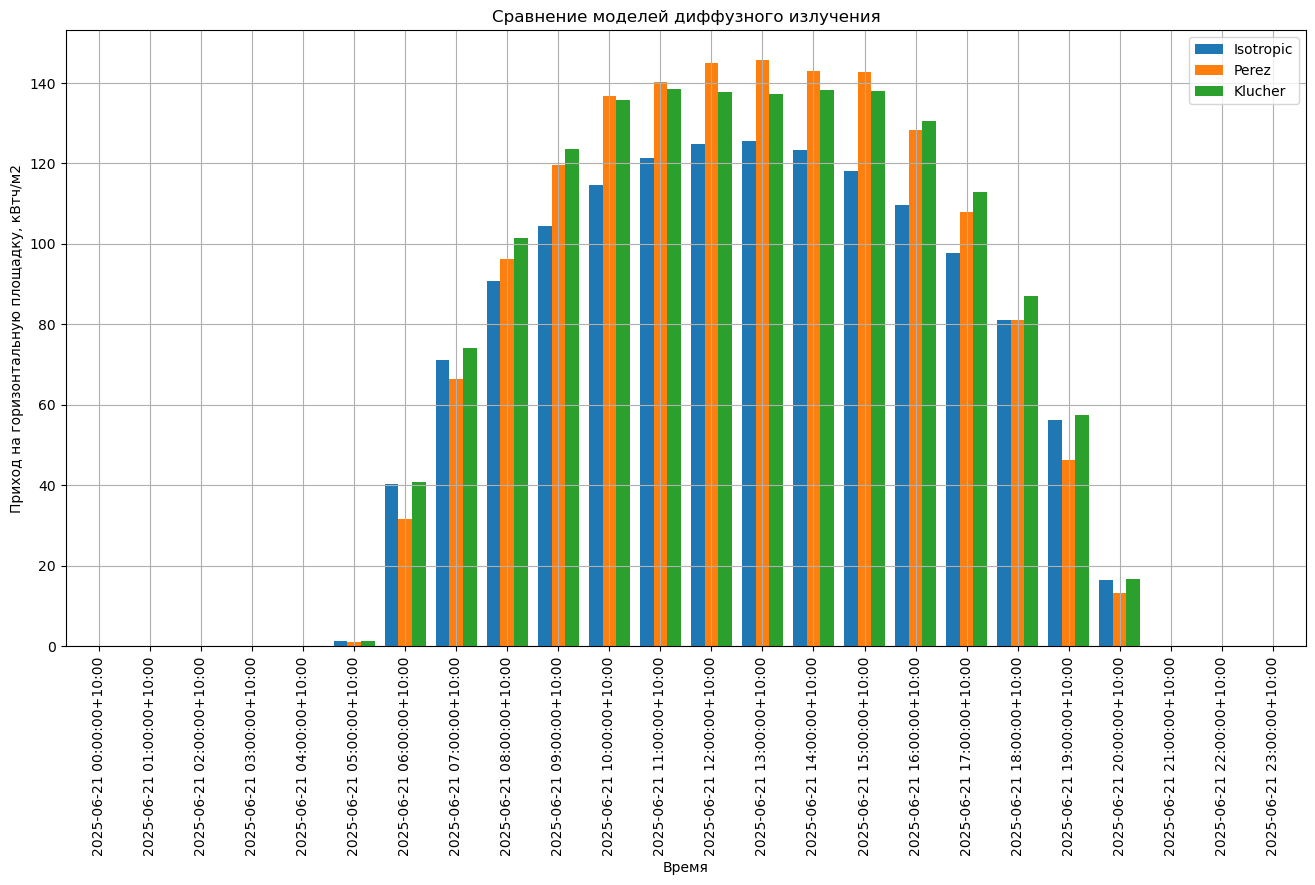

Изотропная модель 1396.5061030888553
Модель Переза 1545.311960663405
Изотропная Клоше 1571.4766066495204


In [56]:
Surface_tilt = loc.latitude - 15
Surface_azimuth = 180

DiffuseSky_isotropic = pvlib.irradiance.isotropic(surface_tilt = Surface_tilt,
                                                  dhi = SCS_summer['dhi'])

DiffuseSky_Perez = pvlib.irradiance.perez(surface_tilt = Surface_tilt ,
                                                 surface_azimuth = Surface_azimuth,
                                                 dhi = SCS_summer['dhi'],
                                                 dni = SCS_summer['dni'],
                                                 dni_extra = DNI_summer,
                                                 solar_zenith = SPA_summer['apparent_zenith'],
                                                 solar_azimuth = SPA_summer['azimuth'],
                                                 airmass = rel_airmass_obj,
                                                 model = 'allsitescomposite1990',
                                                 return_components = False)


DiffuseSky_Klucher = pvlib.irradiance.klucher(surface_tilt = Surface_tilt,
                                              surface_azimuth = Surface_azimuth,
                                              dhi = SCS_summer['dhi'],
                                              ghi = SCS_summer['ghi'],
                                              solar_zenith = SPA_summer['zenith'],
                                              solar_azimuth = SPA_summer['azimuth'])

Diffuse_compare_data = pd.DataFrame(columns = ['Isotropic', 'Perez', 'Klucher'])
Diffuse_compare_data['Isotropic'] = DiffuseSky_isotropic
Diffuse_compare_data['Perez'] = DiffuseSky_Perez
Diffuse_compare_data['Klucher'] = DiffuseSky_Klucher

Diffuse_compare_data.plot(kind = 'bar', figsize = (16,8), width = 0.8)
plt.xlabel('Время')
plt.ylabel('Приход на горизонтальную площадку, кВтч/м2') 
plt.grid()
plt.title('Cравнение моделей диффузного излучения')
plt.show()    

Day_isotropic = sum(Diffuse_compare_data['Isotropic'])
Day_Perez = sum(Diffuse_compare_data['Perez'])
Day_Klucher = sum(Diffuse_compare_data['Klucher'])

print('Изотропная модель',Day_isotropic)
print('Модель Переза',Day_Perez)
print('Изотропная Клоше',Day_Klucher)
